# FinOptix - FAC Summer Project '25

# Assignment - 4

# Black-Litterman Model Implementation

This notebook is part of the FinOptix summer project assignment-4.

You are expected to fill in the missing parts to complete the model.

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Define your stock universe
stocks = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'JNJ', 'PG',
    'V', 'MA', 'HD', 'DIS', 'PFE', 'KO', 'PEP', 'ADBE', 'INTC', 'NFLX'
]

In [ ]:
# Step 2: Download historical data
# --- STUDENTS: Observe the structure and format of the downloaded data ---
data = yf.download(stocks, start="2020-01-01", end="2024-12-31")['Close']
data.dropna(axis=1, inplace=True)  # Drop stocks with missing data

/tmp/ipython-input-196-1147030998.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start="2020-01-01", end="2024-12-31")['Close']
[*********************100%***********************]  20 of 20 completed


In [ ]:
# Step 3: Calculate log returns
# --- STUDENTS: Write a function to calculate log returns ---
def calculate_log_returns(price_df):
    return np.log(price_df / price_df.shift(1)).dropna()
    pass

In [ ]:
returns = calculate_log_returns(data)
returns

Ticker,AAPL,ADBE,AMZN,DIS,GOOGL,HD,INTC,JNJ,JPM,KO,MA,META,MSFT,NFLX,NVDA,PEP,PFE,PG,TSLA,V
Date,,,,,,,,,,,,,,,,,,,,
2020-01-03,-0.009770,-0.007865,-0.012213,-0.011537,-0.005245,-0.003329,-0.012238,-0.011645,-0.013284,-0.005471,-0.009804,-0.005305,-0.012530,-0.011926,-0.016135,-0.001400,-0.005380,-0.006748,0.029203,-0.007985
2020-01-06,0.007937,0.005710,0.014776,-0.005819,0.026305,0.004694,-0.002832,-0.001248,-0.000796,-0.000366,0.002659,0.018659,0.002581,0.030014,0.004185,0.003827,-0.001285,0.001386,0.019072,-0.002165
2020-01-07,-0.004714,-0.000959,0.002089,0.000343,-0.001933,-0.006568,-0.016827,0.006088,-0.017147,-0.007712,-0.003392,0.002161,-0.009159,-0.015242,0.012034,-0.015843,-0.003349,-0.006211,0.038067,-0.002647
2020-01-08,0.015958,0.013348,-0.007839,-0.002061,0.007092,0.014853,0.000679,-0.000138,0.007771,0.001842,0.017491,0.010087,0.015803,0.025404,0.001874,0.005136,0.007968,0.004253,0.048033,0.016973
2020-01-09,0.021018,0.007607,0.004788,-0.003928,0.010443,0.015214,0.005581,0.002962,0.003645,0.018051,0.013025,0.014209,0.012416,-0.010668,0.010923,0.000668,-0.004362,0.010878,-0.022189,0.006906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.003060,-0.000962,0.000622,-0.005639,0.016683,-0.000382,0.034243,0.005522,0.003319,-0.002721,0.001760,0.024641,-0.003097,0.002637,0.036232,-0.009866,0.013190,0.000297,0.022404,-0.001543
2024-12-24,0.011413,0.002683,0.017573,0.010359,0.007575,0.009359,0.009852,0.003985,0.016310,0.007347,0.012680,0.013084,0.009330,0.022425,0.003930,0.009997,0.001123,0.004925,0.070991,0.010755
2024-12-26,0.003171,0.004944,-0.008770,-0.000089,-0.002604,-0.002527,0.001959,-0.001853,0.003420,-0.004306,0.000821,-0.007266,-0.002781,-0.008598,-0.002070,-0.002424,-0.006754,0.007196,-0.017787,0.000811


In [ ]:
# Step 4: Estimate the sample mean and covariance
mu_sample = returns.mean()
cov_sample = returns.cov()

In [ ]:
# Step 5: Assume equal weights for market portfolio (simplification)
w_mkt = np.ones(len(returns.columns)) / len(returns.columns)

In [ ]:
# Step 6: Compute implied equilibrium returns (Pi)
# --- STUDENTS: Fill in this function ---
def implied_returns(cov_matrix, market_weights, risk_aversion):
    # Pi = delta * Sigma * w_mkt
    # Perform matrix multiplication
    # The result should be a vector of shape (N,) or (N, 1)
    # Using @ for matrix multiplication
    return risk_aversion * (cov_matrix @ market_weights)

In [ ]:
risk_aversion = 2.5  # Typical value from literature
pi = implied_returns(cov_sample, w_mkt, risk_aversion)
print(pi.shape)

(20,)


In [ ]:
# Step 7: Formulate Views
# View 1: AAPL will outperform MSFT by 2%
# View 2: TSLA will underperform NVDA by 3%
# View 3: AMZN will outperform DIS by 1.5%
P = np.zeros((3, len(stocks)))
P[0, stocks.index('AAPL')] = 1
P[0, stocks.index('MSFT')] = -1
P[1, stocks.index('TSLA')] = -1
P[1, stocks.index('NVDA')] = 1
P[2, stocks.index('AMZN')] = 1
P[2, stocks.index('DIS')] = -1

Q = np.array([0.02, -0.03, 0.015])

In [ ]:
# Step 8: Define the Omega matrix (view uncertainty)
# --- STUDENTS: Fill in reasonable uncertainties for each view ---
Omega = np.diag([0.0001, 0.0002, 0.0003])   # TODO: Fill in based on confidence (e.g. 0.0001)

In [ ]:
# Step 9: Implement the Black-Litterman Posterior
# --- STUDENTS: Fill in the matrix math for μ_bl and Σ_bl ---
def black_litterman_posterior(cov, pi, P, Q, Omega, tau=0.025):
    # Ensure inputs are numpy arrays
    cov = np.asarray(cov)
    pi = np.asarray(pi)
    P = np.asarray(P)
    Q = np.asarray(Q)
    Omega = np.asarray(Omega)

    # Calculate the inverse of the prior covariance (Sigma)
    cov_inv = np.linalg.inv(cov)
    # Calculate the inverse of the view uncertainty (Omega)
    Omega_inv = np.linalg.inv(Omega)

    # Calculate the posterior covariance (Sigma_BL)
    # Sigma_BL = [(τΣ)^(-1) + PᵀΩ⁻¹P]^(-1)
    cov_bl_inv = tau * cov_inv + P.T @ Omega_inv @ P
    cov_bl = np.linalg.inv(cov_bl_inv)

    # Calculate the posterior expected returns (μ_bl)
    # μ_bl = Σ_BL * [(τΣ)^(-1)π + PᵀΩ⁻¹Q]
    term1 = tau * cov_inv @ pi
    term2 = P.T @ Omega_inv @ Q
    mu_bl = cov_bl @ (term1 + term2)

    # Flatten mu_bl to ensure it's a 1D array for the optimizer
    mu_bl = mu_bl.flatten()

    return mu_bl, cov_bl

In [ ]:
mu_bl, cov_bl = black_litterman_posterior(cov_sample, pi, P, Q, Omega)

In [ ]:
# Step 10: Perform Portfolio Optimization
# --- STUDENTS: Fill in optimizer function to compute optimal weights ---
# Tip: Use scipy.optimize.minimize or cvxpy for quadratic programming
from scipy.optimize import minimize
print(mu_bl.shape, cov_bl.shape)
def mean_variance_opt(mu, cov, allow_short=False):
    # TODO: Maximize Sharpe Ratio or Minimize variance for a target return
    num_assets = len(mu) # Use len(mu) as mu_bl is now a 1D array
    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) -1}
    # Adjust bounds based on allow_short
    if allow_short:
        bounds = None # No bounds for short selling
    else:
        bounds = tuple((0,1) for _ in range(num_assets)) # No short selling

    x0 = np.array([1/num_assets]*num_assets)

    def negative_sharpe_ratio(Weights):
      # Ensure Weights is a numpy array for matrix operations
      Weights = np.asarray(Weights)
      portfolio_return = np.sum(mu * Weights)
      # Reshape Weights to be a row vector for Weights.T @ cov
      weights_row = Weights.reshape(1, -1)
      # Reshape Weights to be a column vector for cov @ Weights
      weights_col = Weights.reshape(-1, 1)
      # Calculate portfolio variance using explicit 2D matrix multiplication
      # (1, N) @ (N, N) @ (N, 1) -> (1, N) @ (N, 1) -> (1, 1)
      portfolio_variance = weights_row @ cov @ weights_col
      # The result is a (1,1) array, extract the scalar value
      portfolio_std = np.sqrt(portfolio_variance[0, 0])

      # Handle potential division by zero if portfolio_std is very close to zero
      if portfolio_std < 1e-9: # Use a small tolerance
          return np.inf # Penalize zero std with infinite negative sharpe

      sharpe_ratio = portfolio_return / portfolio_std
      return -sharpe_ratio

    result = minimize(negative_sharpe_ratio, x0, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

(20,) (20, 20)


In [ ]:

optimal_weights = mean_variance_opt(mu_bl, cov_bl)
optimal_weights = np.round(optimal_weights, decimals=3)


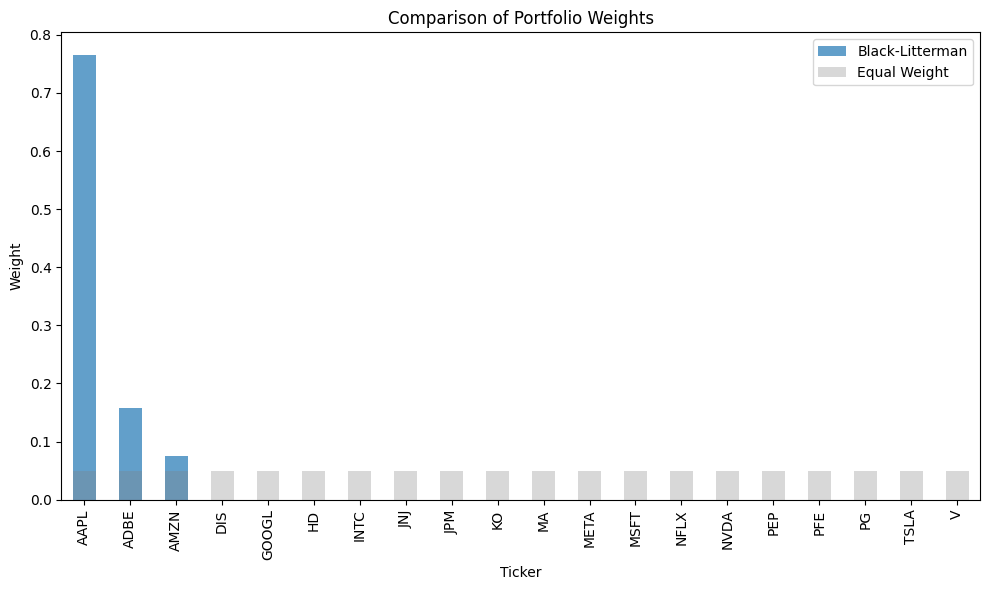

In [ ]:
# Step 11: Analyze and Compare Portfolios
# --- STUDENTS: Plot and compare ---
portfolio_bl = pd.Series(optimal_weights, index=returns.columns)
portfolio_bl = portfolio_bl[portfolio_bl > 0.01].sort_values(ascending=False)

# Also compare with naïve equal weight and market cap weight
portfolio_equal = pd.Series(w_mkt, index=returns.columns)
portfolio_equal = portfolio_equal[portfolio_equal > 0.01].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
portfolio_bl.plot(kind='bar', ax=ax, label='Black-Litterman', alpha=0.7)
portfolio_equal.plot(kind='bar', ax=ax, color='gray', label='Equal Weight', alpha=0.3)
plt.title('Comparison of Portfolio Weights')
plt.ylabel('Weight')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Step 12: Portfolio Performance Simulation
# --- STUDENTS: Evaluate performance ---
def simulate_portfolio(returns, weights):
    # TODO: Compute cumulative returns and plot

    # calculating cumilative returns for both our plot and equal weight plot.
    # lets show porfolio value for the entire time period
    # calculate sharpe_ratio for both
    # risk for both plots.
    # returns is set of log returns

    #convert logarithmic returns to normal fractional reutrns
    returns = np.exp(returns) - 1 # Convert log returns to simple returns first
    portfolio_returns = returns @ weights # this is the daily returns of the portfolio, taking into account the weights

    # Initialize the portfolio value list. Start with 1.0 for an initial investment.
    # We need enough space to store the value for each day.
    portfolio_value = np.zeros(len(portfolio_returns) + 1) # Allocate space for initial value + daily values
    portfolio_value[0] = 1.0 # Starting portfolio value

    # Calculate the cumulative portfolio value over time
    # The loop should go from 1 to len(portfolio_returns) inclusive to fill all daily values
    for i in range(1, len(portfolio_value)):
        # Cumulative value at day i is value at day i-1 multiplied by (1 + return on day i-1)
        portfolio_value[i] = portfolio_value[i-1] * (1 + portfolio_returns.iloc[i-1])


    # Now you can use portfolio_value for plotting or further calculations (e.g., Sharpe Ratio, Risk)
    # Example: Plotting the cumulative value (you can add equal weight comparison here)
    plt.figure(figsize=(12, 6))
    plt.plot(returns.index, portfolio_value[1:], label='Black-Litterman Portfolio Value') # Plot against date index
    plt.title('Portfolio Performance Simulation')
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value (Starting at 1.0)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # You can also calculate Sharpe Ratio and Risk here
    # Daily Sharpe Ratio (adjust for annualization if needed)
    mean_daily_return = portfolio_returns.mean()
    std_daily_return = portfolio_returns.std()
    sharpe_ratio = mean_daily_return / std_daily_return if std_daily_return != 0 else 0
    print(f"Daily Sharpe Ratio: {sharpe_ratio:.4f}")

    # Annualized Sharpe Ratio (assuming 252 trading days)
    annualized_sharpe_ratio = sharpe_ratio * np.sqrt(252)
    print(f"Annualized Sharpe Ratio: {annualized_sharpe_ratio:.4f}")

    # Annualized Volatility (Risk)
    annualized_volatility = std_daily_return * np.sqrt(252)
    print(f"Annualized Volatility (Risk): {annualized_volatility:.4f}")

    # Final Returns
    final_return = (portfolio_value[-1] / portfolio_value[0] - 1)*100
    print(f"Final Returns: {final_return:.4f} %")

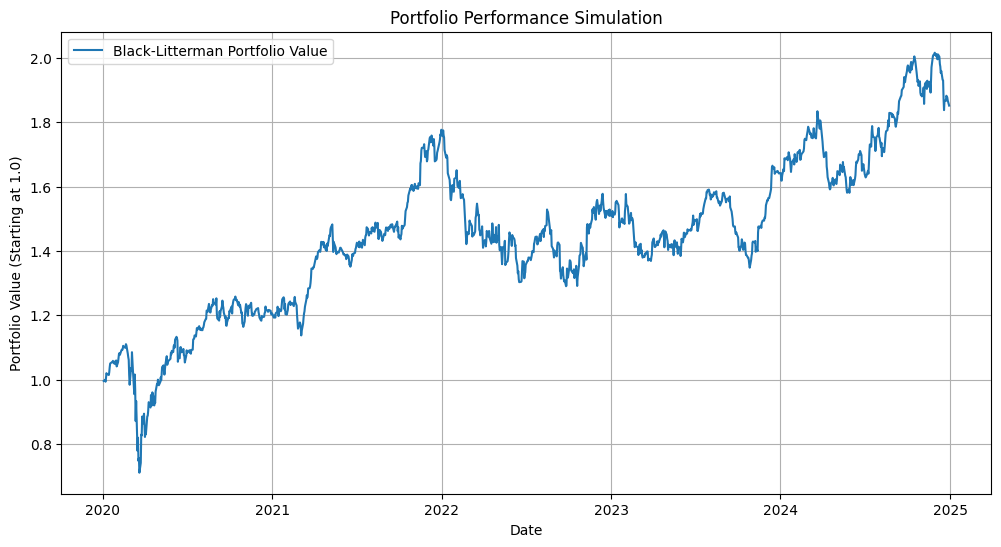

Daily Sharpe Ratio: 0.0394
Annualized Sharpe Ratio: 0.6260
Annualized Volatility (Risk): 0.2467
Final Returns: 85.1715 %


In [ ]:
simulate_portfolio(returns, optimal_weights)  # Uncomment once implemented

[0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05]


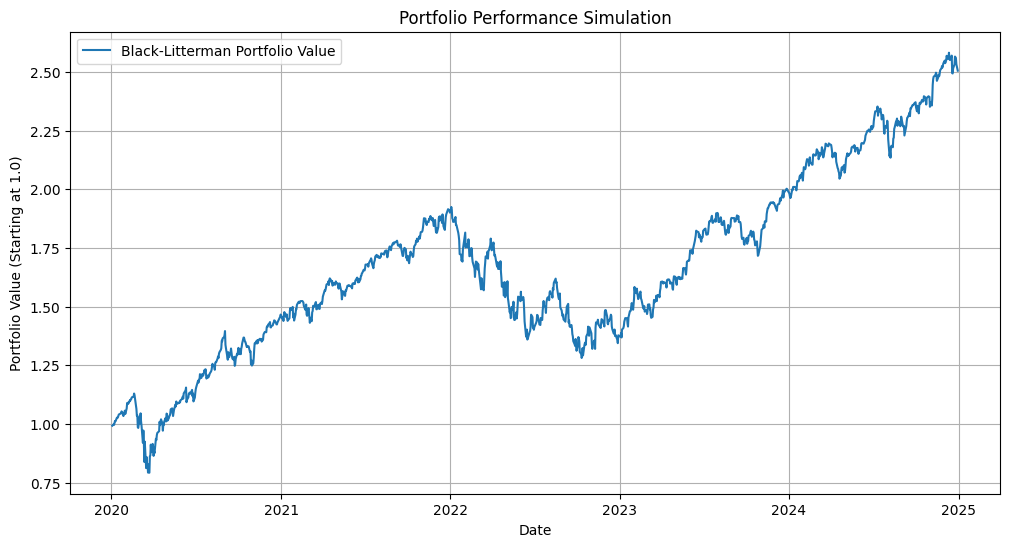

Daily Sharpe Ratio: 0.0573
Annualized Sharpe Ratio: 0.9101
Annualized Volatility (Risk): 0.2323
Final Returns: 150.5072 %


In [ ]:
# Doing the same analysis with equal weigh porfolio
num_assets = len(mu_bl)
equal_weights = np.array([1/num_assets]*num_assets)
print(equal_weights)
simulate_portfolio(returns, equal_weights)

In [ ]:
# --- END OF EXTENDED NOTEBOOK ---